In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [5]:
# Assistant
import pandas as pd
import os

# Check if the file exists before trying to read it
file_path = "data/news.json"

if os.path.exists(file_path):
    df = pd.read_json(file_path)
    print("Dataset Loaded Successfully")
else:
    # Print current working directory to help debug the path issue
    print(f"Current working directory: {os.getcwd()}")
    print(f"File not found: {file_path}")
    
    # Alternative: Try reading from current directory if data folder doesn't exist
    alternative_path = "news.json"
    if os.path.exists(alternative_path):
        df = pd.read_json(alternative_path)
        print("Dataset Loaded Successfully from current directory")
    else:
        print("Please check the file path and ensure the file exists")
        # You can also create an empty DataFrame as fallback
        df = pd.DataFrame()

Current working directory: C:\Users\panka\simi\data
File not found: data/news.json
Dataset Loaded Successfully from current directory


In [6]:
df.head()

,title,url
0,Close Ad,#
1,English,https://www.moneycontrol.com/
2,Hindi,https://hindi.moneycontrol.com
3,Gujarati,https://gujarati.moneycontrol.com/
4,Loans up to ₹50 Lakhs,https://www.moneycontrolpay.com/


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 819
Columns : 2


In [8]:
df.columns

Index(['title', 'url'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   819 non-null    object
 1   url     819 non-null    object
dtypes: object(2)
memory usage: 12.9+ KB


In [10]:
df.isnull().sum()

title    0
url      0
dtype: int64

In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [12]:
df.sample(10)

,title,url
338,Hourly Losers,https://www.moneycontrol.com/stocks/marketstat...
442,Sachin Tendulkar explains what went wrong for ...,https://www.moneycontrol.com/sports/cricket/ip...
614,Can the new NPS retirement income scheme beat ...,https://www.moneycontrol.com/news/business/per...
732,India Business Hour,/https://www.moneycontrol.com/tv/cnbc-tv18-sho...
493,Mecklai Financial,https://www.moneycontrol.com/gamechangers/meck...
39,Price Shockers,https://www.moneycontrol.com/stocks/market-sta...
69,Intraday Large Deals,https://www.moneycontrol.com/markets/stock-dea...
558,Planning,#keypfactb10
523,Show More News,https://www.moneycontrol.com/news/health-and-f...
180,User Profile,javascript:;


In [13]:
df["title_length"] = df["title"].str.len()

df.head()

,title,url,title_length
0,Close Ad,#,8
1,English,https://www.moneycontrol.com/,7
2,Hindi,https://hindi.moneycontrol.com,5
3,Gujarati,https://gujarati.moneycontrol.com/,8
4,Loans up to ₹50 Lakhs,https://www.moneycontrolpay.com/,21


In [14]:
df["title_length"].describe()

count    819.000000
mean      36.452991
std       36.426315
min        1.000000
25%       10.000000
50%       16.000000
75%       70.000000
max      153.000000
Name: title_length, dtype: float64

In [15]:
df.sort_values(
    by="title_length",
    ascending=False
).head(10)

,title,url,title_length
573,Trade Spotlight: How should you trade Adani En...,https://www.moneycontrol.com/news/business/mar...,153
382,Akshay Kumar pens heartfelt birthday note for ...,https://www.moneycontrol.com/entertainment/aks...,143
648,Trade Spotlight: How should you trade Federal ...,https://www.moneycontrol.com/news/business/mar...,140
416,French Proverb Of The Day: 'You have to break ...,https://www.moneycontrol.com/education/french-...,135
652,Trade Spotlight: How should you trade Samvardh...,https://www.moneycontrol.com/news/business/mar...,133
745,Bringing Structure and Reliability to Indiaâ...,https://www.moneycontrol.com/news/podcast/brin...,132
299,"Re-NEET Question Paper for Rs 50,000? Telegram...",https://www.moneycontrol.com/education/re-neet...,131
651,Trade Spotlight: How should you trade Rain Ind...,https://www.moneycontrol.com/news/business/mar...,131
235,Bengaluru ORR flooding: Outer Ring Road Compan...,https://www.moneycontrol.com/news/india/bengal...,130
710,"Fidelity, Goldman Sachs, IMF, Quant MF, WhiteO...",https://www.moneycontrol.com/news/business/mar...,130


In [16]:
df.sort_values(
    by="title_length",
    ascending=True
).head(10)

,title,url,title_length
770,L,https://www.moneycontrol.com/india/stockpriceq...,1
781,W,https://www.moneycontrol.com/india/stockpriceq...,1
780,V,https://www.moneycontrol.com/india/stockpriceq...,1
779,U,https://www.moneycontrol.com/india/stockpriceq...,1
778,T,https://www.moneycontrol.com/india/stockpriceq...,1
767,I,https://www.moneycontrol.com/india/stockpriceq...,1
769,K,https://www.moneycontrol.com/india/stockpriceq...,1
773,O,https://www.moneycontrol.com/india/stockpriceq...,1
783,Y,https://www.moneycontrol.com/india/stockpriceq...,1
784,Z,https://www.moneycontrol.com/india/stockpriceq...,1


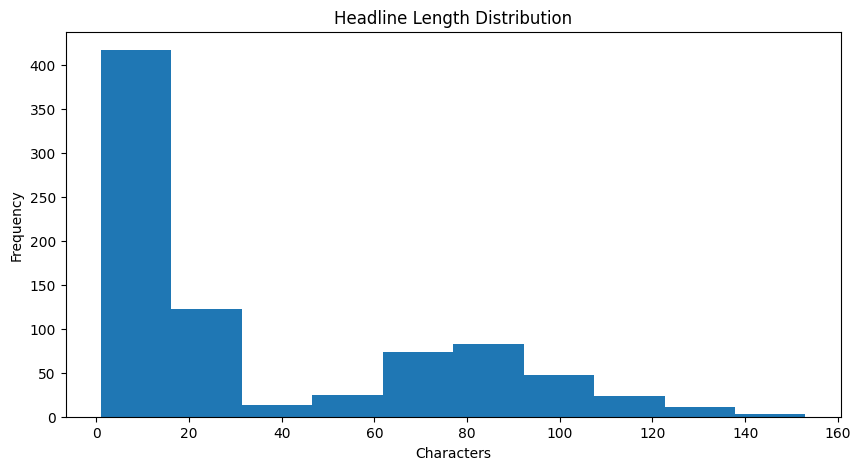

In [17]:
plt.hist(df["title_length"])

plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [18]:
avg = df["title_length"].mean()

print("Average Headline Length :", round(avg,2))

Average Headline Length : 36.45


In [19]:
#Top 20 Long Headlines
top20 = df.nlargest(
    20,
    "title_length"
)

top20[["title","title_length"]]

,title,title_length
573,Trade Spotlight: How should you trade Adani En...,153
382,Akshay Kumar pens heartfelt birthday note for ...,143
648,Trade Spotlight: How should you trade Federal ...,140
416,French Proverb Of The Day: 'You have to break ...,135
652,Trade Spotlight: How should you trade Samvardh...,133
745,Bringing Structure and Reliability to Indiaâ...,132
299,"Re-NEET Question Paper for Rs 50,000? Telegram...",131
651,Trade Spotlight: How should you trade Rain Ind...,131
235,Bengaluru ORR flooding: Outer Ring Road Compan...,130
710,"Fidelity, Goldman Sachs, IMF, Quant MF, WhiteO...",130


In [20]:
df["word_count"] = df["title"].str.split().str.len()

df.head()

,title,url,title_length,word_count
0,Close Ad,#,8,2
1,English,https://www.moneycontrol.com/,7,1
2,Hindi,https://hindi.moneycontrol.com,5,1
3,Gujarati,https://gujarati.moneycontrol.com/,8,1
4,Loans up to ₹50 Lakhs,https://www.moneycontrolpay.com/,21,5


In [21]:
df["word_count"].describe()

count    819.000000
mean       5.963370
std        5.908316
min        1.000000
25%        2.000000
50%        3.000000
75%       12.000000
max       24.000000
Name: word_count, dtype: float64

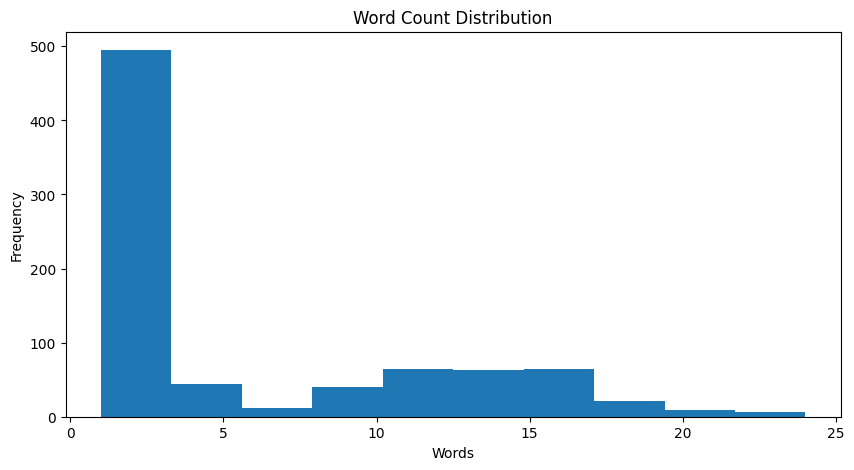

In [22]:
#distribution
plt.hist(df["word_count"])

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [26]:
from collections import Counter

all_words = " ".join(df["title"])

words = all_words.split()

counter = Counter(words)

common_words = counter.most_common(20)

# Fixed: Removed the extra quotes that were causing the syntax error
common_words

[('to', 89),
 ('in', 74),
 ('of', 48),
 ('and', 47),
 ('the', 44),
 ('for', 37),
 ('Rs', 35),
 ('on', 31),
 ('More', 28),
 ('India', 27),
 ('is', 23),
 ('See', 22),
 ('at', 20),
 ('|', 20),
 ('2026', 19),
 ('with', 18),
 ('your', 18),
 ('a', 18),
 ('as', 17),
 ('AI', 16)]

In [28]:

common_df = pd.DataFrame(
    common_words,
    columns=["Word","Frequency"]
)

common_df

,Word,Frequency
0,to,89
1,in,74
2,of,48
3,and,47
4,the,44
5,for,37
6,Rs,35
7,on,31
8,More,28
9,India,27


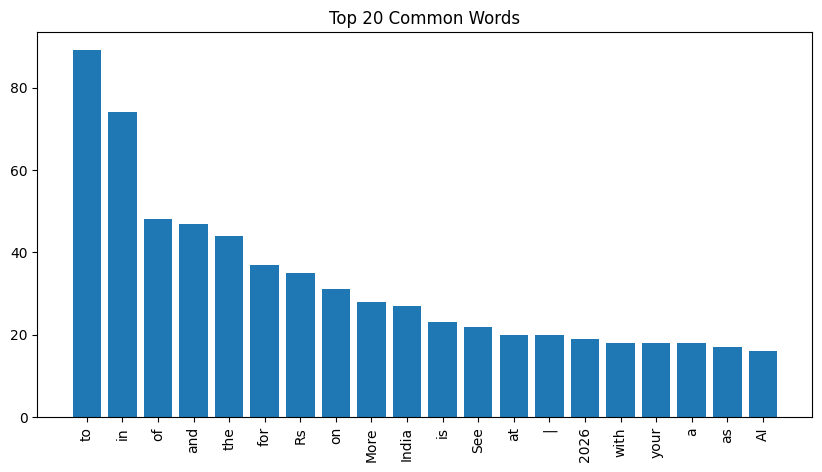

In [29]:
plt.bar(
    common_df["Word"],
    common_df["Frequency"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Common Words")

plt.show()

In [30]:
df.to_csv(
    "moneycontrol_news_cleaned.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


In [31]:
df.head()

,title,url,title_length,word_count
0,Close Ad,#,8,2
1,English,https://www.moneycontrol.com/,7,1
2,Hindi,https://hindi.moneycontrol.com,5,1
3,Gujarati,https://gujarati.moneycontrol.com/,8,1
4,Loans up to ₹50 Lakhs,https://www.moneycontrolpay.com/,21,5
